In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("./fashion-mnist_test.csv")

In [3]:
df = df.drop(['label'], axis=1)


In [4]:
arr = df.to_numpy('uint8')

In [5]:
arr.shape, arr.dtype

((10000, 784), dtype('uint8'))

In [6]:
def stitch_images(data, grid_rows, grid_cols, img_dim=28):
    """
    data: np.ndarray of shape (N, 784)
    grid_rows: how many images tall the result is
    grid_cols: how many images wide the result is
    """
    n_images = grid_rows * grid_cols
    
    # 1. Grab the subset of images and reshape to 2D
    # Shape: (n_images, 28, 28)
    rng = np.random.default_rng()
    subset = rng.choice(data, size=n_images, replace=True, axis=0).reshape(n_images, img_dim, img_dim)
    # 2. Reshape into the grid structure
    # Shape: (grid_rows, grid_cols, 28, 28)
    grid = subset.reshape(grid_rows, grid_cols, img_dim, img_dim)
    
    # 3. Transpose to align rows correctly
    # We want (grid_rows, img_dim) to be the first two dims to form the vertical axis
    # and (grid_cols, img_width) to form the horizontal axis.
    # Current: (0:g_rows, 1:g_cols, 2:img_h, 3:img_w)
    # Target:  (0:g_rows, 2:img_h, 1:g_cols, 3:img_w)
    stitched = grid.transpose(0, 2, 1, 3)
    
    # 4. Flatten back to the requested row-major 1D array
    # Final shape will be (grid_rows * 28 * grid_cols * 28,)
    return stitched.ravel()
stiched_image = stitch_images(arr, 4,4)

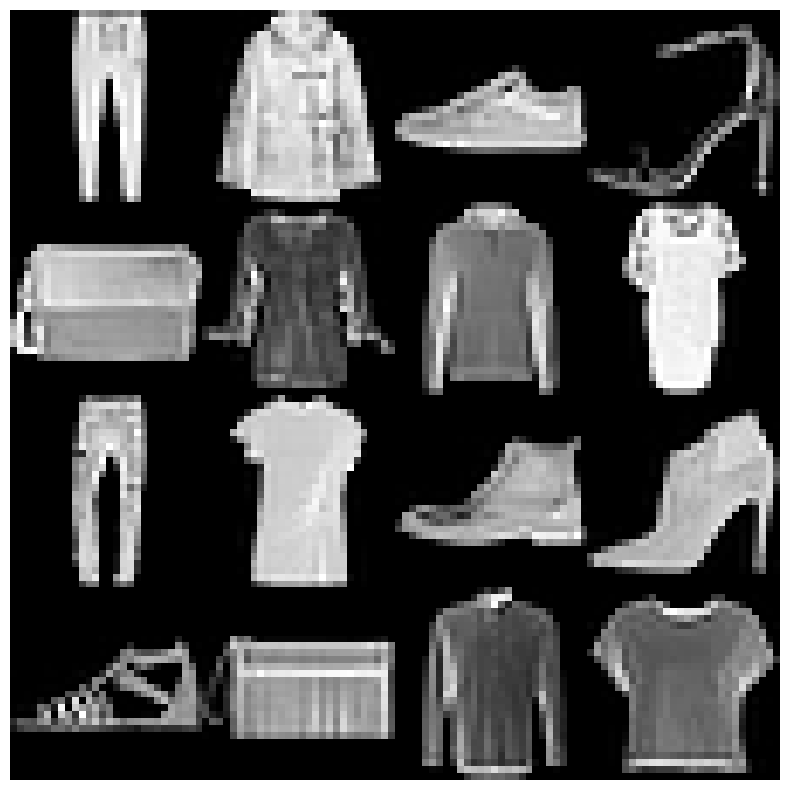

In [7]:
import matplotlib.pyplot as plt

def show_stitched_image(data_1d, grid_rows, grid_cols, img_dim=28):
    # 1. Calculate the final 2D dimensions
    total_height = grid_rows * img_dim
    total_width = grid_cols * img_dim
    
    # 2. Reshape the 1D byte array into a 2D matrix
    image_2d = data_1d.reshape(total_height, total_width)
    
    # 3. Plot it
    plt.figure(figsize=(10, 10))
    # Use cmap='gray' since these are greyscale intensities
    plt.imshow(image_2d, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')  # Hide the pixel coordinate axes
    plt.show()

# Example Usage:
# large_image_data = stitch_images(my_data, 5, 5)
# show_stitched_image(large_image_data, 5, 5)
show_stitched_image(stiched_image, 4, 4)

In [8]:
from sobel_reference import sobel_reference

In [9]:
magnitude, direction = sobel_reference(stiched_image.reshape(4*28,4*28))

In [10]:
magnitude.shape, 4*28

((110, 110), 112)

In [11]:
print(magnitude.min(), magnitude.max())

print(direction.min(), direction.max(), np.pi)

0.0 1054.1082
0.0 186.34175600183897
-3.1399825 3.1415927 3.141592653589793


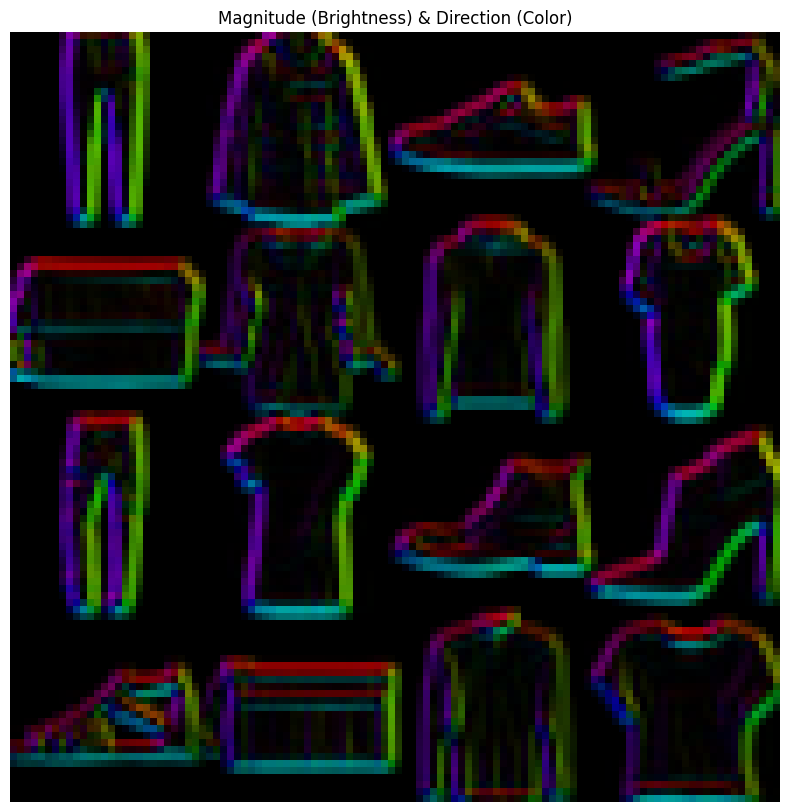

In [13]:
from matplotlib.colors import hsv_to_rgb
def visualize_vector_field(mag, direction, h, w):
    """
    mag: 2D array of floats (0-255)
    direction: 2D array of floats (-pi to pi)
    """
    MAX_SOBEL_VALUE = np.sqrt(2) * 4 * 255 # when gx,gy = 255; technically over esimate
    mag = mag/MAX_SOBEL_VALUE*255
    
    mag = mag.reshape(h,w)

    direction = direction.reshape(h,w)
    
    # 1. Create an empty HSV image
    # Shape: (height, width, 3)
    hsv = np.zeros((h, w, 3), dtype=np.float32)
    
    # 2. Map Direction to Hue [0, 1]
    # We shift -pi...pi to 0...2pi, then normalize to 0...1
    hsv[..., 0] = (direction + np.pi) / (2 * np.pi)
    
    # 3. Set Saturation to maximum
    hsv[..., 1] = 1.0
    
    # 4. Map Magnitude to Value [0, 1]
    # Ensure it's clipped and normalized
    hsv[..., 2] = np.clip(mag, 0, 255) / 255.0
    
    # 5. Convert HSV to RGB for display
    rgb = hsv_to_rgb(hsv)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb)
    plt.title("Magnitude (Brightness) & Direction (Color)")
    plt.axis('off')
    plt.show()
visualize_vector_field(magnitude, direction, 4*28-2, 4*28-2)

In [14]:
stiched_image.tofile("stitched_image.img.bin")
combined_floats = np.concatenate([magnitude, direction])
combined_floats.tofile("kernel_results.magdir.bin")